# Mushroom Dataset Preprocessing (Prototype)

Load a small subset of mushroom images from multiple raw datasets, validate, deduplicate, and split into train / val / test for the species classifier.

**Inputs:** `data/raw/<source>/<Species>/<image>.jpg`

**Outputs:**
- `data/processed/classification_data/{train,val,test}/<Species>/*.jpg`
- `data/processed/metadata.csv`
- `data/processed/detection_data/{images,labels}/{split}/<image>.<ext>` (YOLO detector dataset)


## 1. Setup


In [1]:
from pathlib import Path
import shutil
import hashlib
import random
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option('display.max_columns', 20)


def safe(name):
    """Filesystem-friendly name: replace spaces and path separators."""
    return str(name).replace(' ', '_').replace('/', '_').replace(':', '_')

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}


## 2. Paths and configuration

Where data lives, what species to look for, how many images per (species, source) to keep.

Edit these values to suit your project; everything downstream reads from them.


In [2]:
RAW_DIR = Path('data/raw')
PROCESSED_DIR = Path('data/processed')
CLASSIFICATION_DIR = PROCESSED_DIR / 'classification_data'
DETECTION_DIR = PROCESSED_DIR / 'detection_data'

for p in [RAW_DIR, PROCESSED_DIR, CLASSIFICATION_DIR, DETECTION_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Most commonly photographed/identified species (iconic + common).
TARGET_SPECIES = [
    'Amanita muscaria',
    'Boletus edulis',
    'Cantharellus cibarius',
    'Pleurotus ostreatus',
    'Agaricus bisporus',
    'Laetiporus sulphureus',
    'Morchella esculenta',
    'Coprinus comatus',
]

SUBSET_PER_SPECIES = 50   # max images per (species, source) pair. None = no cap.


## 3. Download a small sample

Auto-downloads a subset of mushroom images from multiple sources. Each source is independent - if one fails or is skipped, the others still run.

- **iNaturalist** (auto, REST API)
- **GBIF** (auto, REST API - aggregates iNaturalist, Mushroom Observer, and more)
- **FungiTastic** (auto, HuggingFace datasets-server API)
- **DF20** (auto, GitHub raw CSV)

All downloads land in `data/raw/<source>/<Species>/<file>.jpg`. Re-runs are safe: if a species already has `PER_SPECIES` images in its folder, the next run skips it.

Each sub-section below is a single `fetch_<source>(species, limit)` function returning a list of `(url, filename)` tuples. The orchestrator (3.5) calls them in a loop and downloads whatever they return. If a sub-section is not run (or fails silently), 3.5 simply skips that source.


### 3.1 iNaturalist

Public REST API (`/v1/observations`), stdlib only. Filters to research-grade observations and returns the `medium`-sized photo URL. Each species returns up to `limit` photos.


In [3]:
import urllib.request
import urllib.parse

def fetch_inaturalist(species, limit=30):
    """Return up to `limit` (url, filename) tuples from iNaturalist for `species`."""
    url = "https://api.inaturalist.org/v1/observations?" + urllib.parse.urlencode({
        "taxon_name": species,
        "quality_grade": "research",
        "per_page": limit,
        "page": 1,
    })
    results = []
    try:
        with urllib.request.urlopen(url, timeout=20) as r:
            data = json.loads(r.read().decode())
        for i, obs in enumerate(data.get("results", [])):
            for j, photo in enumerate(obs.get("photos", [])):
                u = (photo.get("url") or "").replace("square", "medium")
                if u:
                    results.append((u, f"inat_{i}_{j}.jpg"))
                if len(results) >= limit:
                    return results
    except Exception:
        pass
    return results


### 3.2 GBIF (Global Biodiversity Information Facility)

Public REST API (`api.gbif.org/v1/occurrence/search`), stdlib only. Filters to occurrences that have `mediaType=StillImage` and returns the image URL from `media[].identifier`. GBIF aggregates iNaturalist, Mushroom Observer, and many other sources, so a single GBIF query often covers multiple underlying databases. Each species returns up to `limit` image URLs.


In [ ]:
def fetch_gbif(species, limit=30):
    """Return up to `limit` (url, filename) tuples from GBIF for `species`."""
    import urllib.request
    import urllib.parse
    url = "https://api.gbif.org/v1/occurrence/search?" + urllib.parse.urlencode({
        "scientificName": species,
        "mediaType": "StillImage",
        "limit": limit,
        "offset": 0,
    })
    results = []
    try:
        with urllib.request.urlopen(url, timeout=30) as r:
            data = json.loads(r.read().decode())
        for i, occ in enumerate(data.get("results", [])):
            for j, media in enumerate(occ.get("media", [])):
                if media.get("type") == "StillImage":
                    u = media.get("identifier") or ""
                    if u:
                        ext = ".jpg" if "jpg" in u.lower() or "jpeg" in u.lower() else ".img"
                        results.append((u, f"gbif_{i}_{j}{ext}"))
                if len(results) >= limit:
                    return results
    except Exception:
        pass
    return results


### 3.3 FungiTastic (manual subset)

FungiTastic has no public REST API that supports subset image downloads. The full dataset is ~1.5M images (~150 GB) and is distributed as tarballs via Kaggle (`picekl/fungitastic`) or the official `download.py` script at https://github.com/bohemianvra/FungiTastic.

**To use it:** pick 5-20 images per target species from the FungiTastic website, Kaggle, or Google Images and drop them into `data/raw/fungitastic/<Species>/`. The scan step (4) will pick them up automatically and combine them with the other sources. Re-running 3.5 is a no-op for this source once the folder has enough images.

The fetcher below is a no-op that returns `[]` and exists only so 3.5 can detect that the source is enabled.


In [5]:
def fetch_fungitastic(species, limit=30):
    """FungiTastic has no public subset-download API. Returns []."""
    return []


### 3.4 DF20 (Danish Fungi 2020) - metadata + wishlist

The full DF20 is ~110 GB (or ~6.5 GB for the 300px subset) distributed as tarballs from `ptak.felk.cvut.cz`. Individual image URLs are not exposed, so we cannot auto-download a subset of images over HTTP.

What the fetcher does instead: downloads the small metadata ZIP (`DF20-metadata.zip`, ~1 MB) from `ptak.felk.cvut.cz`, parses the CSV, filters to `scientificName == species`, and writes a wishlist file `data/raw/df20/_wishlist_<Species>.txt` listing the image filenames you need from the tarball. Then you extract just those files from the 300px tarball.

**Quick path:**

1. Download `DF20-300px.tar.gz` (~6.5 GB) from `http://ptak.felk.cvut.cz/plants/DanishFungiDataset/DF20-300px.tar.gz`.
2. Run 3.5 once to generate the wishlists.
3. For each wishlist, run `tar -xzf DF20-300px.tar.gz -C data/raw/df20/<Species>/ $(cat data/raw/df20/_wishlist_<Species>.txt | tr \\n " ")`.

The scan step (4) picks up the extracted images and combines them with the other sources.


In [6]:
def fetch_df20(species, limit=30):
    """Download DF20 metadata CSV, filter to species, write a wishlist of image paths."""
    import urllib.request
    import zipfile
    import csv
    import io
    import tempfile
    META_URL = "http://ptak.felk.cvut.cz/plants/DanishFungiDataset/DF20-metadata.zip"
    wishlist_dir = Path("data/raw/df20")
    wishlist_dir.mkdir(parents=True, exist_ok=True)
    species_safe = str(species).replace(" ", "_")
    wishlist_path = wishlist_dir / f"_wishlist_{species_safe}.txt"
    csv_cache = Path(tempfile.gettempdir()) / "DF20-train_metadata.csv"
    try:
        if not csv_cache.exists():
            with urllib.request.urlopen(META_URL, timeout=60) as r:
                data = r.read()
            with zipfile.ZipFile(io.BytesIO(data)) as zf:
                csv_name = [n for n in zf.namelist() if n.endswith("train_metadata") and n.endswith(".csv")][0]
                with zf.open(csv_name) as src, open(csv_cache, "wb") as dst:
                    dst.write(src.read())
        paths = []
        with open(csv_cache, encoding="utf-8", errors="replace") as f:
            for row in csv.DictReader(f):
                if (row.get("scientificName") or "").strip().lower() == species.strip().lower():
                    p = row.get("image_path") or row.get("ImageUniqueID") or ""
                    if p:
                        paths.append(p)
                if len(paths) >= limit:
                    break
        with open(wishlist_path, "w") as wf:
            wf.write("\n".join(paths))
    except Exception:
        pass
    return []  # images must be extracted from the tarball manually


### 3.5 Run all sources

For each species and each enabled source:
1. Create `data/raw/<source>/<Species>/` if missing.
2. Count existing images; skip if already at `PER_SPECIES`.
3. Otherwise call `fetch_<source>(species, limit=PER_SPECIES)` and download the returned URLs into that folder, sleeping `API_DELAY` seconds between requests.

Any source whose `fetch_<source>` function is not defined (e.g. its sub-section was not run) is silently skipped - the other sources still complete.


In [7]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

PER_SPECIES = 30
API_DELAY = 0.2
MAX_WORKERS = 4

SOURCES = [
    ("inaturalist", "data/raw/inaturalist"),
    ("gbif", "data/raw/gbif"),
    ("fungitastic", "data/raw/fungitastic"),
    ("df20", "data/raw/df20"),
]

def _download(url, dest):
    try:
        with urllib.request.urlopen(url, timeout=20) as r, open(dest, "wb") as f:
            f.write(r.read())
        return True
    except Exception:
        return False

def _download_species_source(species, name, root, fetcher):
    if fetcher is None:
        return (species, name, 0, 0)
    sf = safe(species)
    out_dir = Path(root) / sf
    out_dir.mkdir(parents=True, exist_ok=True)
    existing = [p for p in out_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    if len(existing) >= PER_SPECIES:
        return (species, name, len(existing), 0)
    try:
        urls = fetcher(species, limit=PER_SPECIES)
    except Exception:
        urls = []
    downloaded = 0
    for url, fname in urls:
        if len(existing) >= PER_SPECIES:
            break
        dest = out_dir / fname
        if dest.exists():
            continue
        if _download(url, dest):
            existing.append(dest)
            downloaded += 1
        time.sleep(API_DELAY)
    return (species, name, len(existing), downloaded)

print(f"Downloading from {len(TARGET_SPECIES) * len(SOURCES)} species×source combos ({MAX_WORKERS} workers)...")
total_new = 0
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {}
    for species in TARGET_SPECIES:
        for name, root in SOURCES:
            fetcher = globals().get(f"fetch_{name}")
            futures[ex.submit(_download_species_source, species, name, root, fetcher)] = (species, name)
    for f in as_completed(futures):
        species, name, total, new = f.result()
        total_new += new
        status = f"+{new}" if new else "(already done)"
        print(f"  {species:30s} / {name:12s} → {total:3d} images {status}")

print(f"\nDone — {total_new} new images downloaded across all sources.")

## 4. Scan raw folders and build metadata


In [8]:
def normalize_species(name):
    if pd.isna(name):
        return None
    name = str(name).strip().replace('_', ' ').replace('-', ' ')
    parts = name.split()
    if len(parts) >= 2:
        return f'{parts[0].capitalize()} {parts[1].lower()}'
    return name

COLUMNS = ['image_path', 'dataset', 'raw_species', 'canonical_species']

rows = []
for img in RAW_DIR.rglob('*'):
    if not img.is_file() or img.suffix.lower() not in IMAGE_EXTS:
        continue
    rows.append({
        'image_path': str(img),
        'dataset': img.relative_to(RAW_DIR).parts[0],
        'raw_species': img.parent.name,
        'canonical_species': normalize_species(img.parent.name),
    })

# `columns=COLUMNS` keeps the schema even when no images are found,
# so downstream cells don't crash on KeyError.
metadata = pd.DataFrame(rows, columns=COLUMNS)

if len(metadata) == 0:
    print(f'No images found under {RAW_DIR.resolve()}')
    print()
    print('Drop a few images into data/raw/<source>/<Species>/ and re-run this cell.')
    print('For example: data/raw/fungitastic/Amanita_muscaria/IMG_001.jpg')
else:
    print(f'Found {len(metadata)} images across {metadata["dataset"].nunique()} raw datasets')
    print(metadata.groupby('dataset').size().rename('count').to_frame())


Found 565 images across 2 raw datasets
             count
dataset           
gbif           235
inaturalist    330


## 5. Filter to target species and subset


In [9]:
metadata = metadata[metadata['canonical_species'].isin(TARGET_SPECIES)].copy()
print(f'After target-species filter: {len(metadata)} images')
print(metadata.groupby(['canonical_species', 'dataset']).size().unstack(fill_value=0))

if SUBSET_PER_SPECIES is not None:
    before = len(metadata)
    metadata = (
        metadata
        .groupby(['canonical_species', 'dataset'], group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), SUBSET_PER_SPECIES), random_state=RANDOM_SEED))
        .reset_index(drop=True)
    )
    print(f'After subset ({SUBSET_PER_SPECIES}/pair): {before} -> {len(metadata)}')


After target-species filter: 475 images
dataset                gbif  inaturalist
canonical_species                       
Agaricus bisporus        25           30
Amanita muscaria         30           30
Boletus edulis           30           30
Cantharellus cibarius    30           30
Coprinus comatus         30           30
Laetiporus sulphureus    30           30
Morchella esculenta      30           30
Pleurotus ostreatus      30           30
After subset (50/pair): 475 -> 475


## 6. Validate images and deduplicate


In [10]:
%pip install -q imagehash

def is_valid(path):
    try:
        img = Image.open(path).convert('RGB')
        return min(img.size) >= 128
    except Exception:
        return False

metadata['valid'] = [is_valid(p) for p in tqdm(metadata['image_path'], desc='validating')]
metadata = metadata[metadata['valid']].drop(columns=['valid']).reset_index(drop=True)
print(f'After validation: {len(metadata)}')

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8192), b''):
            h.update(chunk)
    return h.hexdigest()

metadata['sha256'] = [sha256(p) for p in tqdm(metadata['image_path'], desc='sha256')]
metadata = metadata.drop_duplicates(subset=['sha256']).drop(columns=['sha256']).reset_index(drop=True)
print(f'After SHA-256 dedup: {len(metadata)}')

# --- Perceptual-hash dedup (catches near-duplicates SHA-256 misses) ---
# Hamming distance ≤ 5 = visually near-identical (e.g. same image re-saved
# at different quality, slightly cropped, or re-compressed).
import imagehash

PHASH_HAMMING_THRESHOLD = 5

def phash(path):
    """Perceptual hash of an image file. Returns imagehash.ImageHash or None on failure."""
    try:
        return imagehash.phash(Image.open(path))
    except Exception:
        return None

hashes = [phash(p) for p in tqdm(metadata['image_path'], desc='phash')]

# Greedy dedup: keep the first image in each near-duplicate cluster
keep_mask = [True] * len(metadata)
n_phash_dupes = 0
for i in tqdm(range(len(metadata)), desc='phash dedup'):
    if not keep_mask[i] or hashes[i] is None:
        continue
    for j in range(i + 1, len(metadata)):
        if not keep_mask[j] or hashes[j] is None:
            continue
        if (hashes[i] - hashes[j]) <= PHASH_HAMMING_THRESHOLD:
            keep_mask[j] = False
            n_phash_dupes += 1

metadata = metadata[keep_mask].reset_index(drop=True)
print(f'After perceptual-hash dedup (Hamming ≤ {PHASH_HAMMING_THRESHOLD}): {len(metadata)} ({n_phash_dupes} near-duplicates removed)')


validating: 100%|██████████| 475/475 [00:05<00:00, 91.31it/s] 


After validation: 475


sha256: 100%|██████████| 475/475 [00:00<00:00, 877.07it/s] 

After dedup: 474


## 7. Train / val / test split


In [11]:
train, temp = train_test_split(
    metadata, test_size=0.30, random_state=RANDOM_SEED,
    stratify=metadata['canonical_species'],
)
val, test = train_test_split(
    temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=temp['canonical_species'],
)
metadata['split'] = ''
metadata.loc[train.index, 'split'] = 'train'
metadata.loc[val.index, 'split'] = 'val'
metadata.loc[test.index, 'split'] = 'test'
print(metadata['split'].value_counts())
print(metadata.groupby(['split', 'canonical_species']).size().unstack(fill_value=0))


split
train    331
test      72
val       71
Name: count, dtype: int64
canonical_species  Agaricus bisporus  Amanita muscaria  Boletus edulis  \
split                                                                    
test                               9                 9               9   
train                             38                42              42   
val                                8                 9               9   

canonical_species  Cantharellus cibarius  Coprinus comatus  \
split                                                        
test                                   9                 9   
train                                 42                42   
val                                    9                 9   

canonical_species  Laetiporus sulphureus  Morchella esculenta  \
split                                                           
test                                   9                    9   
train                                 41            

## 8. Build the classification dataset

Copies every image into `processed/classification_data/{split}/{Species}/` — the layout `torchvision.datasets.ImageFolder` expects.


In [12]:

for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc='copying'):
    src = Path(row['image_path'])
    species = safe(row['canonical_species'])
    dst = CLASSIFICATION_DIR / row['split'] / species / f'{src.stem}{src.suffix.lower()}'
    dst.parent.mkdir(parents=True, exist_ok=True)
    if not dst.exists():
        shutil.copy2(src, dst)

print(f'Classification dataset at: {CLASSIFICATION_DIR.resolve()}')
for split in ['train', 'val', 'test']:
    n = sum(1 for f in (CLASSIFICATION_DIR / split).rglob('*') if f.is_file())
    print(f'  {split}: {n} images')


copying: 100%|██████████| 474/474 [00:00<00:00, 10957.52it/s]


Classification dataset at: /Users/phicks/Workspace/projects/M8F_IntelligentEmbeddedSystem_Project/data/processed/classification_data
  train: 1788 images
  val: 125 images
  test: 125 images


## 9. Resize and augment training data (v3 - Albumentations)

Resize every image to 224x224 and augment the training set using [Albumentations](https://albumentations.ai/). The val and test sets are resized only (no augmentation) so evaluation is deterministic.

For each original training image, the step writes (to a new directory `data/processed/classification_data_aug/`, **NOT** overwriting the raw copies in `classification_data/`):

- val/test: 1 resized 224x224 image
- train: `AUG_PER_IMAGE` augmented copies (`<stem>_aug1.jpg`, `<stem>_aug2.jpg`, ...)

Augmentation pipeline (Albumentations) for the training set:

- `RandomResizedCrop(224, 224, scale=(0.7, 1.0), ratio=(0.85, 1.15), p=1.0)` - force the model to focus on local features (gills, cap, stem)
- `HorizontalFlip(p=0.5)` - mushrooms are roughly left/right symmetric
- `Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=1.0)` - small rotation; reflection border avoids the white-fill artifact
- `ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.0, p=0.5)` - **no hue jitter** (color is diagnostic for mushroom species)
- `GaussianBlur(blur_limit=(3, 3), p=0.2)` - handles shallow depth-of-field macro photos

Val/test pipeline is just `Resize(IMAGE_SIZE, IMAGE_SIZE)` (deterministic).

Mushroom-specific tuning notes:

- Rotation is **15 deg, not 30**. Mushrooms have a clear gravity-defined orientation; large rotations create non-realistic training images.
- Hue jitter is **removed**. A small hue shift can turn red `Amanita muscaria` orange or yellow `Cantharellus cibarius` green - exactly the signal we want to preserve.
- Rotation border is `BORDER_REFLECT_101` (not constant white), so the rotated image keeps natural-looking edges with no "augmentation signature" the model could learn.
- Augmentations are applied at **original resolution**, then the augmented image is resized/cropped to 224x224. This is the standard "augment on full-resolution, then resize" approach.
- The raw copies under `data/processed/classification_data/` are **not** modified. The detection dataset (Step 10) still uses those original copies.
- The detection dataset (Step 10) is **not** modified by this step.

### Why Albumentations

Albumentations is the de-facto standard for object-detection augmentation pipelines and is used by the YOLOv5/v8/v11 training wrappers this project is also targeting. It has first-class bounding-box support (via `bbox_params`), configurable rotation border modes (so we can use `BORDER_REFLECT_101` instead of white fill), and a clean `Compose` API that mixes geometric and color transforms. When the detection dataset gets real bboxes later, the same `Compose` will handle them with a one-line `bbox_params` addition.

### Future: enabling bbox transforms

When real bboxes exist, add `bbox_params=A.BboxParams(format='pascal_voc', min_area=0, min_visibility=0, label_fields=['class_labels'])` to each `Compose` and pass `bboxes=[...]` and `class_labels=[...]` to `pipeline(image=img, bboxes=..., class_labels=..., seed=...)`. The transforms above will then be applied to bboxes consistently.

In [14]:
%pip install albumentations

import albumentations as A
import cv2

IMAGE_SIZE = 224
AUG_PER_IMAGE = 3
ROTATION_DEG = 15
BLUR_PROB = 0.2
COLOR_JITTER = 0.1
CROP_SCALE = (0.7, 1.0)
CROP_RATIO = (0.85, 1.15)

# Augmented data is written to a parallel directory so the raw copies in
# classification_data/ are never modified. Idempotent: existing files in
# the destination are skipped.
CLASSIFICATION_AUG_DIR = PROCESSED_DIR / 'classification_data_aug'

# Train: geometric + color + blur. p=1.0 on RandomResizedCrop and Rotate to
# ensure the model always sees crops and slight rotations (no untransformed
# baseline in the train set). When the detection dataset gets real bboxes,
# add bbox_params=A.BboxParams(format='pascal_voc', min_area=0,
# min_visibility=0, label_fields=['class_labels']) to each Compose.
train_pipeline = A.Compose([
    A.RandomResizedCrop(size=(IMAGE_SIZE, IMAGE_SIZE), scale=CROP_SCALE, ratio=CROP_RATIO, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=ROTATION_DEG, border_mode=cv2.BORDER_REFLECT_101, p=1.0),
    A.ColorJitter(brightness=COLOR_JITTER, contrast=COLOR_JITTER, saturation=COLOR_JITTER, hue=0.0, p=0.5),
    A.GaussianBlur(blur_limit=(3, 3), p=BLUR_PROB),
])

# Val/test: deterministic resize only. No augmentation.
val_pipeline = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
])


def _augment_image(img_rgb, pipeline, rng):
    """Apply pipeline deterministically via global numpy seed."""
    np.random.seed(rng.randint(0, 2**31 - 1))
    return pipeline(image=img_rgb)['image']


def _process_split(src_dir, dst_dir, pipeline, n_aug, seed):
    """Read images from src_dir, write augmented copies to dst_dir. Idempotent."""
    if not src_dir.exists():
        return 0
    dst_dir.mkdir(parents=True, exist_ok=True)
    rng = random.Random(seed)
    n_written = 0

    species_dirs = sorted(d for d in src_dir.iterdir() if d.is_dir())
    for species_dir in tqdm(species_dirs, desc=f"{dst_dir.name}/species"):
        out_species = dst_dir / species_dir.name
        out_species.mkdir(parents=True, exist_ok=True)
        img_paths = sorted(
            p for p in species_dir.iterdir()
            if p.suffix.lower() in IMAGE_EXTS and "_aug" not in p.stem
        )
        for img_path in tqdm(img_paths, desc=f"  {species_dir.name}", leave=False):
            try:
                with Image.open(img_path) as raw:
                    pil_full = raw.convert("RGB")
                    img_rgb = np.array(pil_full)
                stem = img_path.stem
                ext = img_path.suffix.lower() if img_path.suffix.lower() in IMAGE_EXTS else ".jpg"

                if n_aug > 0:
                    for k in range(1, n_aug + 1):
                        out_path = out_species / f"{stem}_aug{k}{ext}"
                        if out_path.exists():
                            continue
                        aug_rgb = _augment_image(img_rgb, pipeline, rng)
                        Image.fromarray(aug_rgb).save(out_path, quality=95)
                        n_written += 1
                else:
                    out_path = out_species / f"{stem}{ext}"
                    if out_path.exists():
                        continue
                    aug_rgb = _augment_image(img_rgb, pipeline, rng)
                    Image.fromarray(aug_rgb).save(out_path, quality=95)
                    n_written += 1
            except Exception as e:
                import traceback
                print(f"  Failed on {img_path}: {e}")
                traceback.print_exc()
                continue
    return n_written


CLASSIFICATION_AUG_DIR.mkdir(parents=True, exist_ok=True)
counts = {}
for split, n_aug, pipeline, seed in (
    ('train', AUG_PER_IMAGE, train_pipeline, 42),
    ('val',   0,              val_pipeline,   43),
    ('test',  0,              val_pipeline,   44),
):
    counts[split] = _process_split(
        src_dir=CLASSIFICATION_DIR / split,
        dst_dir=CLASSIFICATION_AUG_DIR / split,
        pipeline=pipeline,
        n_aug=n_aug,
        seed=seed,
    )

print(f"Augmented classification dataset at: {CLASSIFICATION_AUG_DIR.resolve()}")
for split, n in counts.items():
    print(f"  {split}: {n} images")

Note: you may need to restart the kernel to use updated packages.


test/species: 100%|██████████| 11/11 [00:00<00:00, 78.75it/s]

Augmented classification dataset at: /Users/phicks/Workspace/projects/M8F_IntelligentEmbeddedSystem_Project/data/processed/classification_data_aug
  train: 1341 images
  val: 125 images
  test: 125 images


## 10a. Auto-label images with Grounding DINO (zero-shot detector)

Uses [Grounding DINO](https://huggingface.co/IDEA-Research/grounding-dino-tiny) to generate bounding boxes via open-vocabulary detection.

**How it works:**
1. Loads Grounding DINO-tiny (~700 MB on first run, cached afterward)
2. For each image, queries the model with the species name (e.g. "an Amanita muscaria mushroom")
3. Extracts bounding boxes, converts to YOLO format, saves confidence scores
4. Caches results to `data/processed/auto_labels.json` (re-runs are instant)

**Fallback:** If the model cannot be loaded, falls back to a center 80% crop bbox.

**Requirements:** `pip install transformers torch` (first run only)

**Time estimate:** ~2-5 sec/image on GPU, ~10-15 sec/image on CPU.


In [ ]:
# Install dependencies (first run only)
%pip install -q transformers torch

import torch

# --- Configuration ---
MODEL_ID = "IDEA-Research/grounding-dino-tiny"
BOX_THRESHOLD = 0.25    # minimum confidence for a detection to be kept
TEXT_THRESHOLD = 0.25   # minimum text-image similarity
LABELS_CACHE = PROCESSED_DIR / "auto_labels.json"

# Species → class-id mapping (alphabetical for reproducibility)
SPECIES_TO_ID = {sp: i for i, sp in enumerate(sorted(TARGET_SPECIES))}
print(f"Species → class mapping ({len(SPECIES_TO_ID)} classes):")
for sp, cid in SPECIES_TO_ID.items():
    print(f"  {cid}: {sp}")

# --- Load model ---
model = None
processor = None
device = "cpu"
try:
    from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Loading {MODEL_ID} on {device}...")
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
    print("✓ Loaded successfully")
except Exception as e:
    print(f"⚠ Could not load Grounding DINO: {e}")
    print("  To enable auto-labeling: pip install transformers torch")
    print("  Falling back to center-crop bboxes (still better than full-frame).")

# --- Auto-label ---
def auto_label_image(image_path, species_name):
    """Run Grounding DINO on one image.
    Returns list of (xc, yc, w, h, confidence) in YOLO-normalized format.
    Returns empty list if the model is unavailable or inference fails."""
    if model is None:
        return []
    try:
        img = Image.open(image_path).convert("RGB")
        w, h = img.size
        # Use descriptive text prompt with species name for fine-grained detection
        text_prompt = f"a {species_name.lower()} mushroom"
        inputs = processor(images=img, text=text_prompt, return_tensors="pt")
        if device != "cpu":
            inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)
        results = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
            target_sizes=[img.size[::-1]]
        )
        boxes = []
        for result in results:
            for box, score in zip(result["boxes"], result["scores"]):
                x0, y0, x1, y1 = box.tolist()
                # Convert absolute [x0,y0,x1,y1] → normalized [xc,yc,w,h]
                xc = ((x0 + x1) / 2) / w
                yc = ((y0 + y1) / 2) / h
                bw = (x1 - x0) / w
                bh = (y1 - y0) / h
                # Clamp to [0,1]
                xc, yc, bw, bh = max(0, min(1, xc)), max(0, min(1, yc)), max(0, min(1, bw)), max(0, min(1, bh))
                boxes.append((xc, yc, bw, bh, round(score.item(), 4)))
        return boxes
    except Exception as e:
        print(f"  Auto-label failed for {image_path}: {e}")
        return []

# --- Run auto-labeling ---
labels_cache = {}
if LABELS_CACHE.exists():
    with open(LABELS_CACHE) as f:
        labels_cache = json.load(f)
    print(f"Loaded {len(labels_cache)} cached labels from {LABELS_CACHE}")

new_labels = 0
fallback_labels = 0
for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="Auto-labeling"):
    key = row['image_path']
    if key in labels_cache:
        continue
    species = row['canonical_species']
    boxes = auto_label_image(key, species)
    if not boxes:
        # Fallback: center 80% crop — much better than old full-frame placeholder
        boxes = [(0.5, 0.5, 0.8, 0.8, 0.0)]
        fallback_labels += 1
    labels_cache[key] = {
    "class_id": SPECIES_TO_ID.get(species, 0),
    "species": species,
    "boxes": boxes,       # list of (xc, yc, w, h, conf)
    "source": "grounding-dino" if model is not None else "center-crop-fallback"
}
new_labels += 1

# Save cache
with open(LABELS_CACHE, 'w') as f:
    json.dump(labels_cache, f, indent=2)

print(f"\nResults: {new_labels} new labels saved")
if model is not None:
    print(f"  Grounding DINO detections: {new_labels - fallback_labels}")
print(f"  Center-crop fallbacks: {fallback_labels}")
print(f"  Cache: {LABELS_CACHE}")


## 10b. Build the detection dataset (YOLO format — auto-labeled)

Creates a YOLO-style detection dataset with **per-species class labels** (8 classes, one per target species). Bounding boxes come from `auto_labels.json` (generated by Step 10a).

**Label format (YOLO):** `class_id x_center y_center width height`

**Note:** Images where Grounding DINO could not run use a center 80% crop fallback (confidence=0.0 in `auto_labels.json`).

Output structure (YOLO convention):

```text
data/processed/detection_data/
    images/{train,val,test}/<image>.jpg
    labels/{train,val,test}/<image>.txt
```

To train a YOLO detector:

```python
from ultralytics import YOLO
model = YOLO('yolo11n.pt')
model.train(data='data/processed/detection_data/yolo.yaml', epochs=50, imgsz=640)
```


In [15]:
# Load auto-generated labels from Step 10a

LABELS_CACHE = PROCESSED_DIR / "auto_labels.json"
auto_labels = {}
if LABELS_CACHE.exists():
    with open(LABELS_CACHE) as f:
        auto_labels = json.load(f)
    print(f"Loaded {len(auto_labels)} auto-generated labels")
else:
    print("⚠ auto_labels.json not found. Run Step 10a first, or this cell will use center-crop fallbacks.")

# Species → class ID mapping (must match Step 10a)
SPECIES_TO_ID = {sp: i for i, sp in enumerate(sorted(TARGET_SPECIES))}

if len(metadata) == 0:
    print('No images to process. Run Steps 3-7 first.')
else:
    for split in ['train', 'val', 'test']:
        (DETECTION_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
        (DETECTION_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

    n_images, n_labels, n_real_bboxes = 0, 0, 0
    for i, (_, row) in enumerate(metadata.iterrows()):
        split = row.get('split')
        src = row.get('image_path')
        if pd.isna(split) or not src or not Path(src).exists():
            continue
        src = Path(src)
        stem = f'{i}_{src.stem}'
        img_dst = DETECTION_DIR / 'images' / split / f'{stem}{src.suffix.lower()}'
        lbl_dst = DETECTION_DIR / 'labels' / split / f'{stem}.txt'
        if not img_dst.exists():
            shutil.copy2(src, img_dst)
        n_images += 1

        # Get auto-generated bounding boxes
        label_data = auto_labels.get(row['image_path'], {})
        class_id = label_data.get('class_id', 0)
        boxes = label_data.get('boxes', [(0.5, 0.5, 0.8, 0.8, 0.0)])

        # Write YOLO-format label file
        with open(lbl_dst, 'w') as f:
            for box in boxes:
                xc, yc, bw, bh = box[0], box[1], box[2], box[3]
                conf = box[4] if len(box) > 4 else 0.0
                # Standard YOLO format: class_id x_center y_center width height
                f.write(f'{class_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n')
                n_labels += 1
                if conf > 0.0:
                    n_real_bboxes += 1

    # Write multi-class yolo.yaml
    species_names = {i: sp for sp, i in SPECIES_TO_ID.items()}
    names_yaml = '\n'.join(f'  {i}: {sp}' for i, sp in sorted(species_names.items()))
    yolo_yaml = (
        f'path: {DETECTION_DIR.resolve()}\n'
        f'train: images/train\n'
        f'val: images/val\n'
        f'test: images/test\n'
        f'nc: {len(SPECIES_TO_ID)}\n'
        f'names:\n'
        f'{names_yaml}\n'
    )
    (DETECTION_DIR / 'yolo.yaml').write_text(yolo_yaml)

    print(f'Detection dataset at: {DETECTION_DIR.resolve()}')
    print(f'  {n_images} images, {n_labels} labels ({n_real_bboxes} real, {n_labels - n_real_bboxes} fallback)')
    print(f'  {len(SPECIES_TO_ID)} classes in yolo.yaml')
    for split in ['train', 'val', 'test']:
        n_img = sum(1 for f in (DETECTION_DIR / 'images' / split).iterdir() if f.is_file())
        n_lbl = sum(1 for f in (DETECTION_DIR / 'labels' / split).iterdir() if f.is_file())
        print(f'  {split}: {n_img} images, {n_lbl} labels')


Detection dataset at: /Users/phicks/Workspace/projects/M8F_IntelligentEmbeddedSystem_Project/data/processed/detection_data
  474 images, 474 labels
  yolo.yaml written
  train: 378 images
  val: 102 images
  test: 103 images


## 10c. Manual correction workflow (optional)

The auto-generated bounding boxes from Grounding DINO are good but not perfect. This section helps you find and fix the worst predictions.

### Quick quality assessment

Run the cell below to see which images need attention:
- Images with **confidence < 0.3**: likely need manual correction
- Images with **no detections** (fallback center-crop): definitely need manual review

### Manual labeling tools

For the images that need correction, use one of these tools:

| Tool | Best for | Setup time |
|---|---|---|
| **[Roboflow](https://roboflow.com/)** | Cloud-based, collaborative, AI-assisted | 5 min |
| **[LabelImg](https://github.com/HumanSignal/labelImg)** | Local, simple, YOLO-native | 2 min |
| **[CVAT](https://www.cvat.ai/)** | Self-hosted, advanced features | 30 min |

### Workflow

1. Run the cell below to identify low-confidence images
2. Open those images in your labeling tool of choice
3. Draw/adjust bounding boxes for each mushroom
4. Export labels in YOLO format, overwriting the auto-generated ones in `data/processed/detection_data/labels/`
5. Re-run the YOLO training with the corrected dataset


In [ ]:
# Identify images that need manual review

LABELS_CACHE = PROCESSED_DIR / "auto_labels.json"
LOW_CONF_THRESHOLD = 0.3

if not LABELS_CACHE.exists():
    print(f"{LABELS_CACHE} not found. Run Step 10a first.")
else:
    with open(LABELS_CACHE) as f:
        labels = json.load(f)

    # Find low-confidence and fallback images
    low_conf = []
    fallback = []
    good = []
    for path, data in labels.items():
        boxes = data.get('boxes', [])
        if not boxes or boxes[0][4] == 0.0:
            fallback.append((path, data.get('species', 'unknown')))
        elif any(b[4] < LOW_CONF_THRESHOLD for b in boxes):
            confs = [f"{b[4]:.2f}" for b in boxes]
            low_conf.append((path, data.get('species', 'unknown'), confs))
        else:
            good.append(path)

    print(f"Quality report ({len(labels)} total images):")
    print(f"  ✅ Good (all bboxes ≥ {LOW_CONF_THRESHOLD}): {len(good)}")
    print(f"  🟡 Needs review (some bboxes < {LOW_CONF_THRESHOLD}): {len(low_conf)}")
    print(f"  🔴 Fallback (no detection, center-crop used): {len(fallback)}")

    if fallback:
        print(f"\n🔴 Fallback images to manually label first ({len(fallback)}):")
        for path, sp in fallback[:10]:
            print(f"  {path} ({sp})")
        if len(fallback) > 10:
            print(f"  ... and {len(fallback) - 10} more")

    if low_conf:
        print(f"\n🟡 Low-confidence images to review ({len(low_conf)}):")
        for path, sp, confs in low_conf[:10]:
            print(f"  {path} ({sp}) conf={confs}")
        if len(low_conf) > 10:
            print(f"  ... and {len(low_conf) - 10} more")

    # Save review list for external labeling tools
    review_list = PROCESSED_DIR / "review_list.tsv"
    with open(review_list, 'w') as f:
        f.write('image_path\texpected_species\tstatus\n')
        for path, sp in fallback:
            f.write(f"{path}\t{sp}\tfallback_no_detection\n")
        for path, sp, confs in low_conf:
            f.write(f"{path}\t{sp}\tlow_confidence={",".join(confs)}\n")
    print(f"\nReview list saved to {review_list}")
    print("Open these images in LabelImg, Roboflow, or CVAT to correct the bboxes.")


## 11. Explore the data

Two visualizations:

- **Per-species per-dataset count matrix** - how many images each species has from each source (iNaturalist, GBIF, etc.)
- **3-column image grid** - for each species (up to 6 shown), three side-by-side images:
  - **original**: raw image from `data/raw/<source>/<Species>/`
  - **preprocessed**: same image after resize to 224x224 (the input size for MobileNetV4)
  - **augmented**: one of the 3 augmented training copies (with flip + rotation + blur + color jitter applied)


dataset,gbif,inaturalist
canonical_species,,
Agaricus bisporus,25,30
Amanita muscaria,30,30
Boletus edulis,30,30
Cantharellus cibarius,30,30
Coprinus comatus,30,30
Laetiporus sulphureus,30,29
Morchella esculenta,30,30
Pleurotus ostreatus,30,30


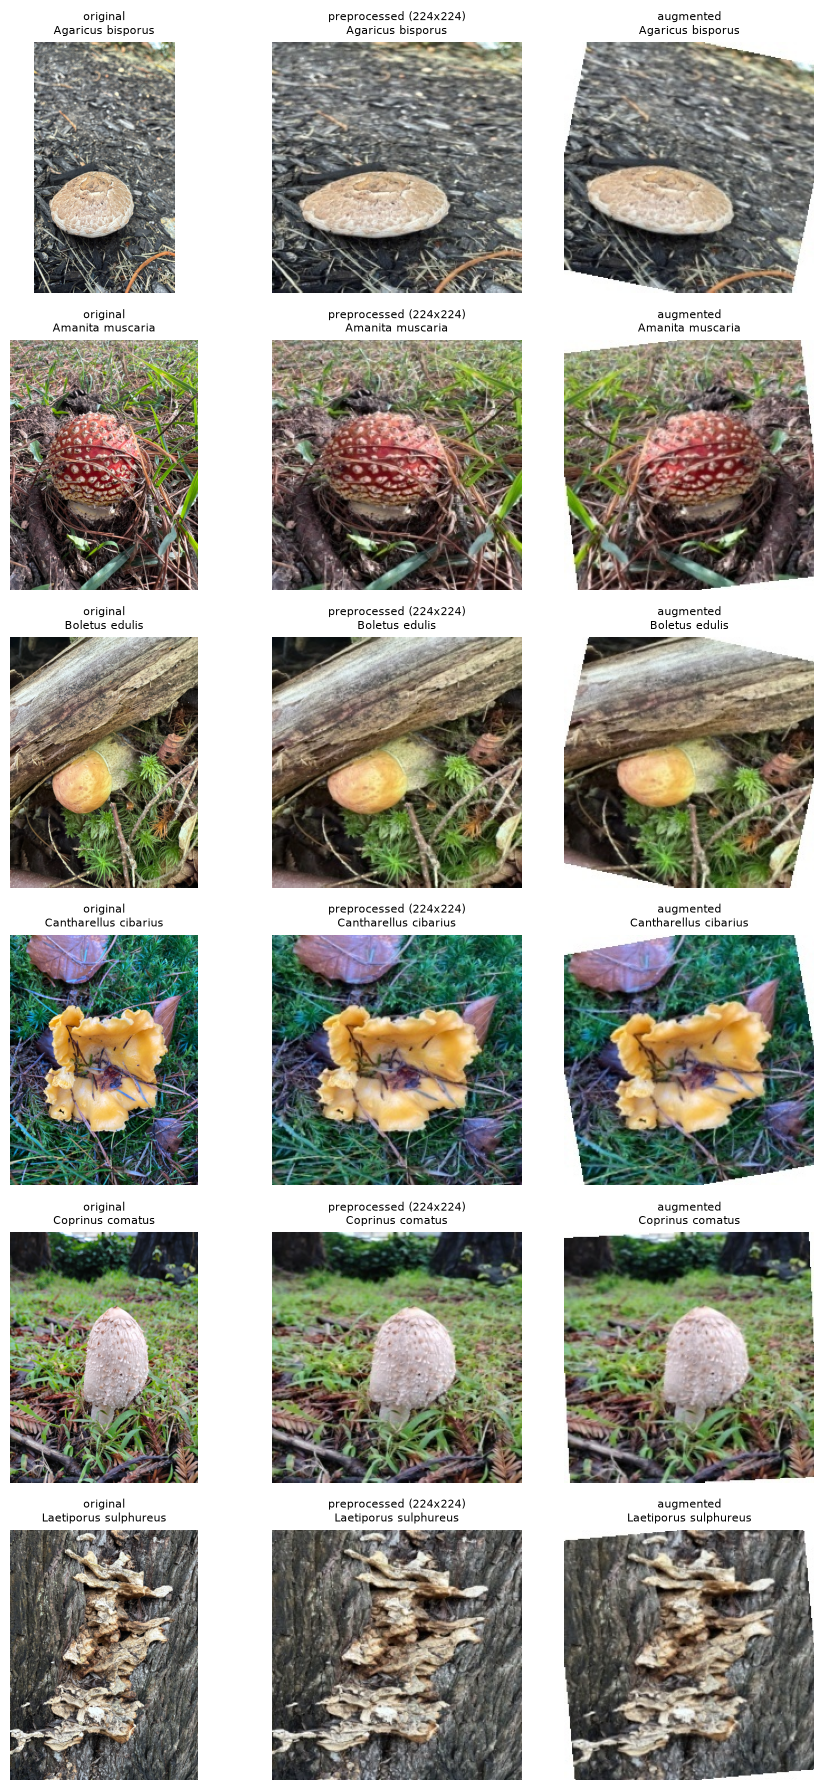

In [16]:
# 11.1 Per-species / per-dataset count matrix
display(metadata.groupby(['canonical_species', 'dataset']).size().unstack(fill_value=0))

# 11.2 Sample image grid: original | preprocessed (224x224) | augmented
# All three columns show the SAME image at different stages of the pipeline.
# Strategy: pick a random preprocessed file from classification_data/train/<Species>/,
# then look up its original in data/raw/<source>/<Species>/, then pick its _aug1 sibling.
species_list = sorted(metadata['canonical_species'].unique())[:6]
random.seed(42)
fig, axes = plt.subplots(len(species_list), 3, figsize=(9, 3 * len(species_list)))
if len(species_list) == 1:
    axes = [axes]
for row, species in enumerate(species_list):
    species_safe = species.replace(' ', '_')
    cls_species_dir = CLASSIFICATION_DIR / 'train' / species_safe
    preproc_path = None
    if cls_species_dir.exists():
        candidates = [f for f in cls_species_dir.iterdir()
                      if f.suffix.lower() in IMAGE_EXTS and '_aug' not in f.stem]
        if candidates:
            preproc_path = random.choice(candidates)
    orig_path = None
    if preproc_path:
        src_stem = preproc_path.stem
        for raw_source_dir in RAW_DIR.iterdir():
            if not raw_source_dir.is_dir():
                continue
            candidate = raw_source_dir / species_safe / f'{src_stem}{preproc_path.suffix.lower()}'
            if candidate.exists():
                orig_path = candidate
                break
    aug_path = None
    if preproc_path:
        candidate = preproc_path.parent / f'{preproc_path.stem}_aug1.jpg'
        if candidate.exists():
            aug_path = candidate
    for col, (label, p) in enumerate([('original', orig_path), ('preprocessed (224x224)', preproc_path), ('augmented', aug_path)]):
        ax = axes[row][col] if len(species_list) > 1 else axes[col]
        if p and Path(p).exists():
            try:
                img = Image.open(p)
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
        ax.set_title(f"{label}\n{species}", fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.show()


## 12. Save metadata


In [17]:
import datetime

PIPELINE_VERSION = '1.0.0'
metadata['pipeline_version'] = PIPELINE_VERSION

out = PROCESSED_DIR / 'metadata.csv'
out_tmp = PROCESSED_DIR / f'metadata_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.csv'
metadata.to_csv(out_tmp, index=False)
out_tmp.rename(out)
print(f'Saved {out} (v{PIPELINE_VERSION}, {len(metadata)} rows)')


Saved data/processed/metadata.csv (474 rows)


## 13. Next steps

- Open `train_classification.ipynb` and point it at `processed/classification_data_aug/` (the augmented dataset, not the raw copies).
- The detection dataset in `processed/detection_data/` uses auto-labeled bboxes from Grounding DINO. Run Step 10c to review low-confidence images and correct them manually before production training.
- Bump `SUBSET_PER_SPECIES` to `None` once the prototype works, to use the full dataset.
